# UNSUPERVISED LEARNING EXPERIMENTS FOR ALL THE TASKS
**Hypothesis:** This set of experiments are done to assess the linear separability of the signal between classes. Under the hypothesis that unconclusive results in unsupervised separability mean that the task is more difficult than expected.

**Content of the file:** This file contains the experiments for both tasks. Fisrs a binary label clustering trial, where PCA is projected and k-means applied then compared through a confusion matrix. Then a multilabel experiment comparing the PCA projection and the Kmeans with the true labels for every dataset.

### Imports and Paths

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy import signal
from scipy.stats import kurtosis, skew
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder, normalize
from sklearn.metrics import (
    silhouette_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    adjusted_rand_score,
    normalized_mutual_info_score)
from scipy.optimize import linear_sum_assignment


In [ ]:
'''from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/Shareddrives/CompBioMed/seminars"
'''

'from google.colab import drive\ndrive.mount(\'/content/drive\')\n\nbase_path = "/content/drive/Shareddrives/CompBioMed/seminars"\n'

In [ ]:
base_path = ''
PATH_ALIGNED_ECGS = os.path.join(base_path, 'outputs', 'aligned_ecgs.pkl')
PATH_IDENTIFIERS  = os.path.join(base_path, 'outputs', 'identifiers.pkl')

PATH_CARTO = os.path.join(base_path, 'data', 'QRS_CARTO2.mat')
PATH_CHINA = os.path.join(base_path, 'data', 'QRS_Database2.mat')
PATH_SIMS  = os.path.join(base_path, 'data', 'QRS_Sims2.mat')

LABEL_COL = 'Final_Label'

PATH_BINARY_PARQUET = os.path.join(base_path, "data", "binary_full_dataset.parquet")
PATH_MULTICLASS_PARQUET = os.path.join(base_path, "data", "multiclass_full_dataset.parquet")

LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
SUBLOCATION_MAPPING = {
    'LCC': 0, 'RCC': 1, 'COMMISSURE': 2, 'LVOT Subvalvular': 3,
    'LVOT Summit': 4, 'RVOT Septum': 5, 'RFW': 6, 'Undefined': 7
}
CHAMBER_MAPPING = {'LV': 0, 'RV': 1}

RANDOM_STATE= 42

### Utilities

In [ ]:
def _build_binary_target(dSim: dict, data_key: str) -> np.ndarray:
    """Builds an LV (0) vs RV (1) binary classification target array."""
    mapping = {'LV': 0, 'RV': 1}
    key_name = 'LeftRight' if 'LeftRight' in dSim[data_key].dtype.names else 'LeftRigth'
    raw_labels = dSim[data_key][key_name]
    y = np.zeros(len(raw_labels[0]), dtype=np.int64)
    for i, label in enumerate(raw_labels[0]):
        y[i] = mapping[label[0]]
    return y

def _normalize_string_label(label_str: str) -> int:
    """Standardizes heterogeneous anatomical names across MAT strings and Parquet frames."""
    label_str = str(label_str).strip()
    if label_str in ['LCCRCC', 'LCC-RCC']:
        label_str = 'COMMISSURE'
    elif label_str in ['Posteroseptal', 'Anteroseptal']:
        label_str = 'RVOT Septum'
    elif label_str == "AMC":
        label_str = 'LVOT Subvalvular'
    elif label_str == "Summit":
        label_str = 'LVOT Summit'
    elif label_str in ["RV", "-", "RVOTOther", "nan", "None", ""]:
        label_str = 'Undefined'
    return SUBLOCATION_MAPPING.get(label_str, SUBLOCATION_MAPPING['Undefined'])

def _handle_sublocation_safe(dSim: dict, data_key: str) -> np.ndarray:
    """Safely extracts sublocation anatomical regions without dropping samples."""
    if "Sublocation" not in dSim[data_key].dtype.names:
        n_samples = len(dSim[data_key]['I'][0])
        return np.full(n_samples, SUBLOCATION_MAPPING['Undefined'], dtype=np.int64)

    raw_labels = dSim[data_key]["Sublocation"]
    y_sub = []
    for label in raw_labels[0]:
        try:
            label_str = 'Undefined' if len(label) == 0 else str(label[0]).strip()
            y_sub.append(_normalize_string_label(label_str))
        except Exception:
            y_sub.append(SUBLOCATION_MAPPING['Undefined'])
    return np.array(y_sub)

def load_mat_dataset(path: str, data_key: str, sample_size: int, is_multiclass: bool = False):
    """
    Standardized matrix loader supporting both flat binary arrays and multi-dimensional shapes.
    """
    print(f"Loading MATLAB dataset: {path}")
    dSim = loadmat(path)
    n_patients = dSim[data_key][LEADS[0]].shape[1]

    if is_multiclass:
        X = np.zeros((n_patients, len(LEADS), sample_size))
    else:
        X = np.zeros((n_patients, len(LEADS) * sample_size))

    for iLead, lead in enumerate(LEADS):
        lead_data = dSim[data_key][lead]
        for i in range(n_patients):
            patient_signal = lead_data[0, i]
            signal_1d = np.asarray(patient_signal).squeeze()
            if signal_1d.ndim != 1:
                continue
            resampled = signal.resample(signal_1d, sample_size)

            if is_multiclass:
                if np.max(np.abs(resampled)) > 0:
                    resampled = resampled / np.max(np.abs(resampled))
                X[i, iLead, :] = resampled
            else:
                start, end = iLead * sample_size, (iLead + 1) * sample_size
                X[i, start:end] = resampled.flatten()

    if not is_multiclass:
        X = normalize(X, norm="l1")

    y = _build_binary_target(dSim, data_key)
    y_sub = _handle_sublocation_safe(dSim, data_key)
    return X, y, y_sub

def match_cluster_labels(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """Matches unsupervised cluster IDs with true labels to fix arbitrary label switching."""
    idx_0 = (y_pred == 0)
    idx_1 = (y_pred == 1)

    acc_direct = np.mean(y_pred == y_true)

    y_flipped = np.zeros_like(y_pred)
    y_flipped[idx_0] = 1
    y_flipped[idx_1] = 0
    acc_flipped = np.mean(y_flipped == y_true)

    return y_flipped if acc_flipped > acc_direct else y_pred

def load_teknon_dataset(parquet_path: str, label_column: str):
    """Synchronizes raw clinical sequence tensors with descriptive tabular metadata targets."""
    print(f"Loading Teknon database pipeline from: {parquet_path}")
    with open(PATH_ALIGNED_ECGS, 'rb') as f:
        aligned_ecgs = pickle.load(f)
    X_teknon_all = np.array(aligned_ecgs, dtype=np.float32)

    if X_teknon_all.shape[1] != 12 and X_teknon_all.shape[2] == 12:
        X_teknon_all = np.transpose(X_teknon_all, (0, 2, 1))

    with open(PATH_IDENTIFIERS, 'rb') as f:
        df_id = pickle.load(f)

    df_full = pd.read_parquet(parquet_path)
    y_tabular = df_full[label_column]
    common_indices = df_id.index.intersection(y_tabular.index)

    y_raw = y_tabular.loc[common_indices].values
    ecg_positions = [df_id.index.get_loc(idx) for idx in common_indices]
    X_tek = X_teknon_all[ecg_positions]

    encoder = LabelEncoder()
    y_tek = encoder.fit_transform(y_raw)
    return X_tek, y_tek, encoder

def extract_features(X_data: np.ndarray) -> (np.ndarray, list):
    """
    Transforms structural raw matrices into engineered 72-dimensional morphological profiles.
    Supported dimensions: [N, 12, S] or flat [N, 12 * S] arrays.
    """
    if X_data.ndim == 2:
        X_data = X_data.reshape(len(X_data), len(LEADS), -1)

    records = []
    for i_pat in range(len(X_data)):
        feats = {}
        for i_lead, lead in enumerate(LEADS):
            sig = X_data[i_pat, i_lead, :]
            r_amp = np.max(sig)
            s_amp = np.min(sig)
            feats[f'{lead}_R_amp'] = r_amp
            feats[f'{lead}_S_amp'] = s_amp
            feats[f'{lead}_RS_ratio'] = r_amp / (abs(s_amp) + 1e-6)
            feats[f'{lead}_RMS'] = np.sqrt(np.mean(sig**2))
            feats[f'{lead}_Kurtosis'] = kurtosis(sig)
            feats[f'{lead}_Skewness'] = skew(sig)
        records.append(feats)
    df = pd.DataFrame(records)
    return df.values.astype(np.float32), df.columns.tolist()



def match_multiclass_labels(y_true, y_pred, n_clusters=7):
    """Matches multiclass cluster labels with true anatomical identifiers using the Hungarian algorithm."""
    cm = confusion_matrix(y_true, y_pred, labels=range(n_clusters))
    # We maximize the trace (correct classifications) by minimizing cost = -cm
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[c] for c in y_pred])

### 1. Binary Label Clustering Experiments

Loading MATLAB dataset: data\QRS_CARTO2.mat
Loading MATLAB dataset: data\QRS_Sims2.mat
Loading MATLAB dataset: data\QRS_Database2.mat
Loading Teknon database pipeline from: data\binary_full_dataset.parquet

===== Profile: CARTO (Clinic) =====
  Shape: (43, 72)
  Silhouette Score: 0.4062
  Accuracy (Matched): 0.5116

===== Profile: CHINA (Database) =====
  Shape: (333, 72)
  Silhouette Score: 0.2854
  Accuracy (Matched): 0.8679

===== Profile: SIMS (Synthetic) =====
  Shape: (2496, 72)
  Silhouette Score: 0.1902
  Accuracy (Matched): 0.8277

===== Profile: TEKNON (Clinical) =====
  Shape: (177, 72)
  Silhouette Score: 0.1661
  Accuracy (Matched): 0.5593


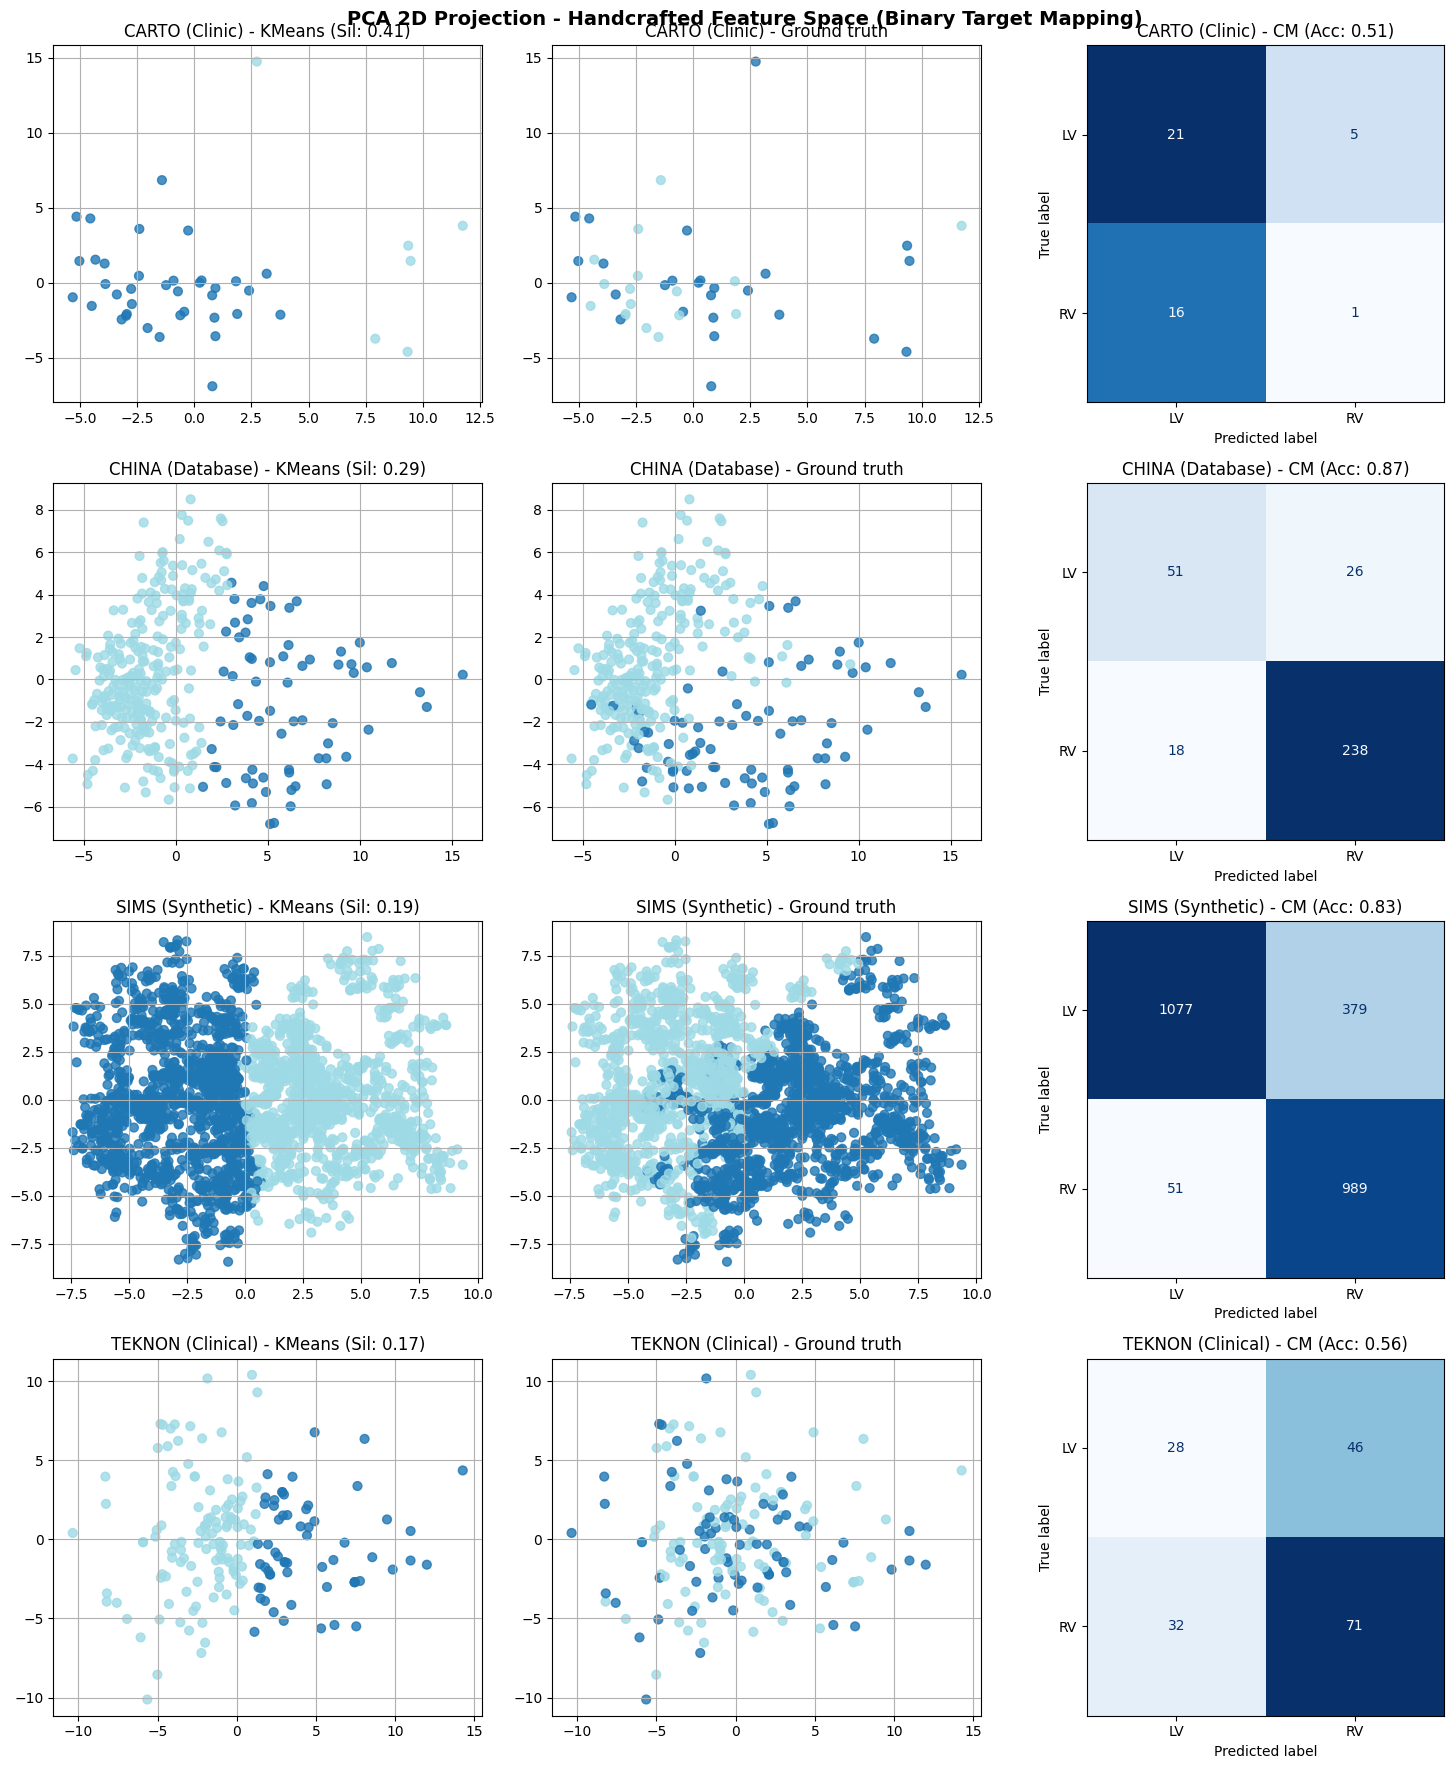

In [ ]:
X_Clinic_bin, y_Clinic_bin, _ = load_mat_dataset(PATH_CARTO, 'QRS_CARTO', sample_size=10, is_multiclass=False)
X_Sims_bin, y_Sims_bin, _ = load_mat_dataset(PATH_SIMS, 'QRS_Sims', sample_size=10, is_multiclass=False)
X_China_bin, y_China_bin, _ = load_mat_dataset(PATH_CHINA, 'QRS', sample_size=10, is_multiclass=False)
X_tek_bin, y_tek_bin, encoder_bin = load_teknon_dataset(PATH_BINARY_PARQUET, 'Chamber_Type')

# Extract statistical features
F_tek_bin, feat_names = extract_features(X_tek_bin)
F_Clinic_bin, _ = extract_features(X_Clinic_bin)
F_China_bin, _ = extract_features(X_China_bin)
F_Sims_bin, _ = extract_features(X_Sims_bin)

binary_experiments = [
    ('CARTO (Clinic)', F_Clinic_bin, y_Clinic_bin),
    ('CHINA (Database)', F_China_bin, y_China_bin),
    ('SIMS (Synthetic)', F_Sims_bin, y_Sims_bin),
    ('TEKNON (Clinical)', F_tek_bin, y_tek_bin)
]

# Execution of latent reductions (PCA) & K-Means clustering
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 18), squeeze=False)
fig.suptitle('PCA 2D Projection - Handcrafted Feature Space (Binary Target Mapping)', fontsize=14, fontweight='bold')

for idx, (name, F_matrix, y_true) in enumerate(binary_experiments):
    F_scaled = StandardScaler().fit_transform(F_matrix)
    F_pca10 = PCA(n_components=10).fit_transform(F_scaled)
    F_vis = PCA(n_components=2).fit_transform(F_scaled)

    # Predict over standard latent space
    clusters = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=20).fit_predict(F_pca10)
    clusters_mapped = match_cluster_labels(y_true, clusters)

    # Calculate performance indicators
    sil_score = silhouette_score(F_pca10, clusters)
    acc = np.mean(clusters_mapped == y_true)
    cm = confusion_matrix(y_true, clusters_mapped)

    print(f"\n===== Profile: {name} =====")
    print(f"  Shape: {F_matrix.shape}")
    print(f"  Silhouette Score: {sil_score:.4f}")
    print(f"  Accuracy (Matched): {acc:.4f}")

    # Column 0: KMeans Cluster Map
    axes[idx, 0].scatter(F_vis[:, 0], F_vis[:, 1], c=clusters, cmap="tab20", s=40, alpha=0.8)
    axes[idx, 0].set_title(f"{name} - KMeans (Sil: {sil_score:.2f})")
    axes[idx, 0].grid(True)

    # Column 1: Ground Truth Map
    axes[idx, 1].scatter(F_vis[:, 0], F_vis[:, 1], c=y_true, cmap="tab20", s=40, alpha=0.8)
    axes[idx, 1].set_title(f"{name} - Ground truth")
    axes[idx, 1].grid(True)

    # Column 2: Confusion Matrix Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LV', 'RV'])
    disp.plot(ax=axes[idx, 2], cmap='Blues', colorbar=False)
    axes[idx, 2].set_title(f"{name} - CM (Acc: {acc:.2f})")

plt.tight_layout()
plt.show()

### 2. Sublocation Clustering Experiments

Loading MATLAB dataset: data\QRS_Sims2.mat
Loading MATLAB dataset: data\QRS_Database2.mat
Loading MATLAB dataset: data\QRS_CARTO2.mat
Loading Teknon database pipeline from: data\multiclass_full_dataset.parquet

Executing Sublocation Pipeline on: Simulations (SIMS)
  > Accuracy (Matched): 0.3582
  > Adjusted Rand Index (ARI): 0.1019
  > Normalized Mutual Info (NMI): 0.2285


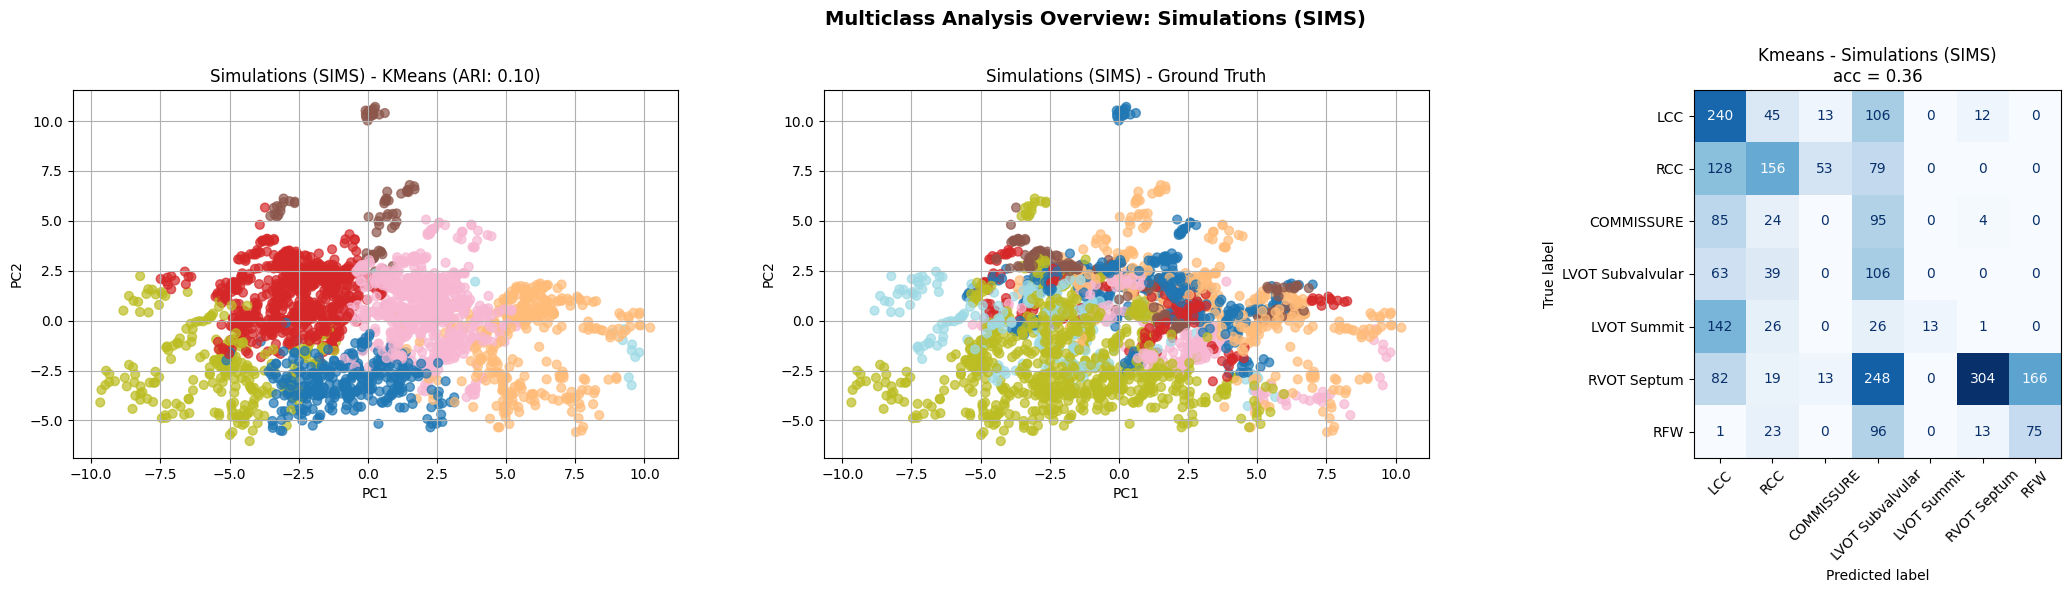


Executing Sublocation Pipeline on: Database (CHINA)
  > Accuracy (Matched): 0.3003
  > Adjusted Rand Index (ARI): 0.0858
  > Normalized Mutual Info (NMI): 0.2003


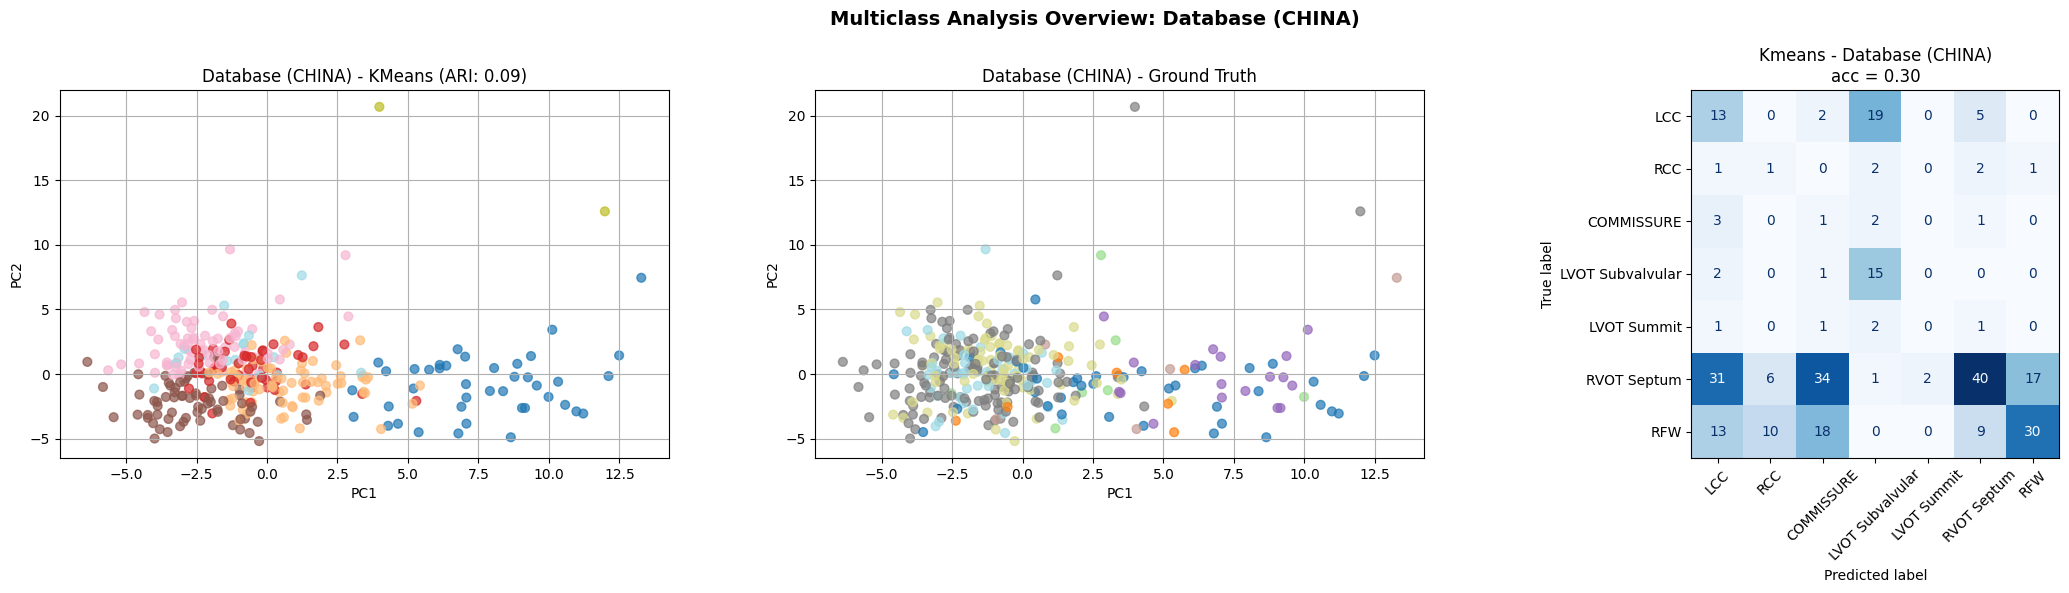


Executing Sublocation Pipeline on: Clinical Mapping (CARTO)
  > Accuracy (Matched): 0.2093
  > Adjusted Rand Index (ARI): 0.1042
  > Normalized Mutual Info (NMI): 0.3022


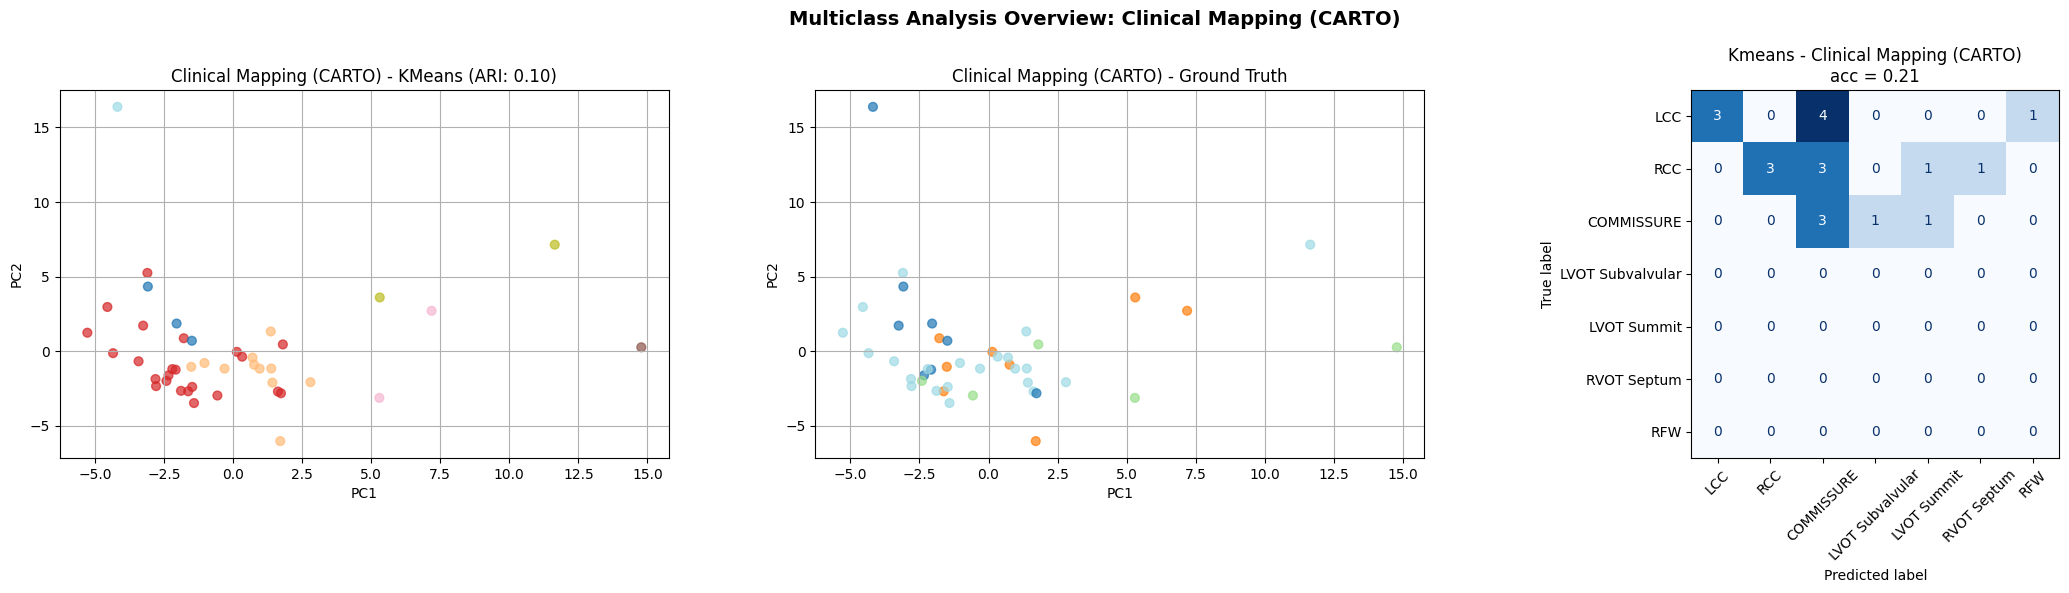


Executing Sublocation Pipeline on: Teknon Sequence
  > Accuracy (Matched): 0.2486
  > Adjusted Rand Index (ARI): 0.0054
  > Normalized Mutual Info (NMI): 0.0712


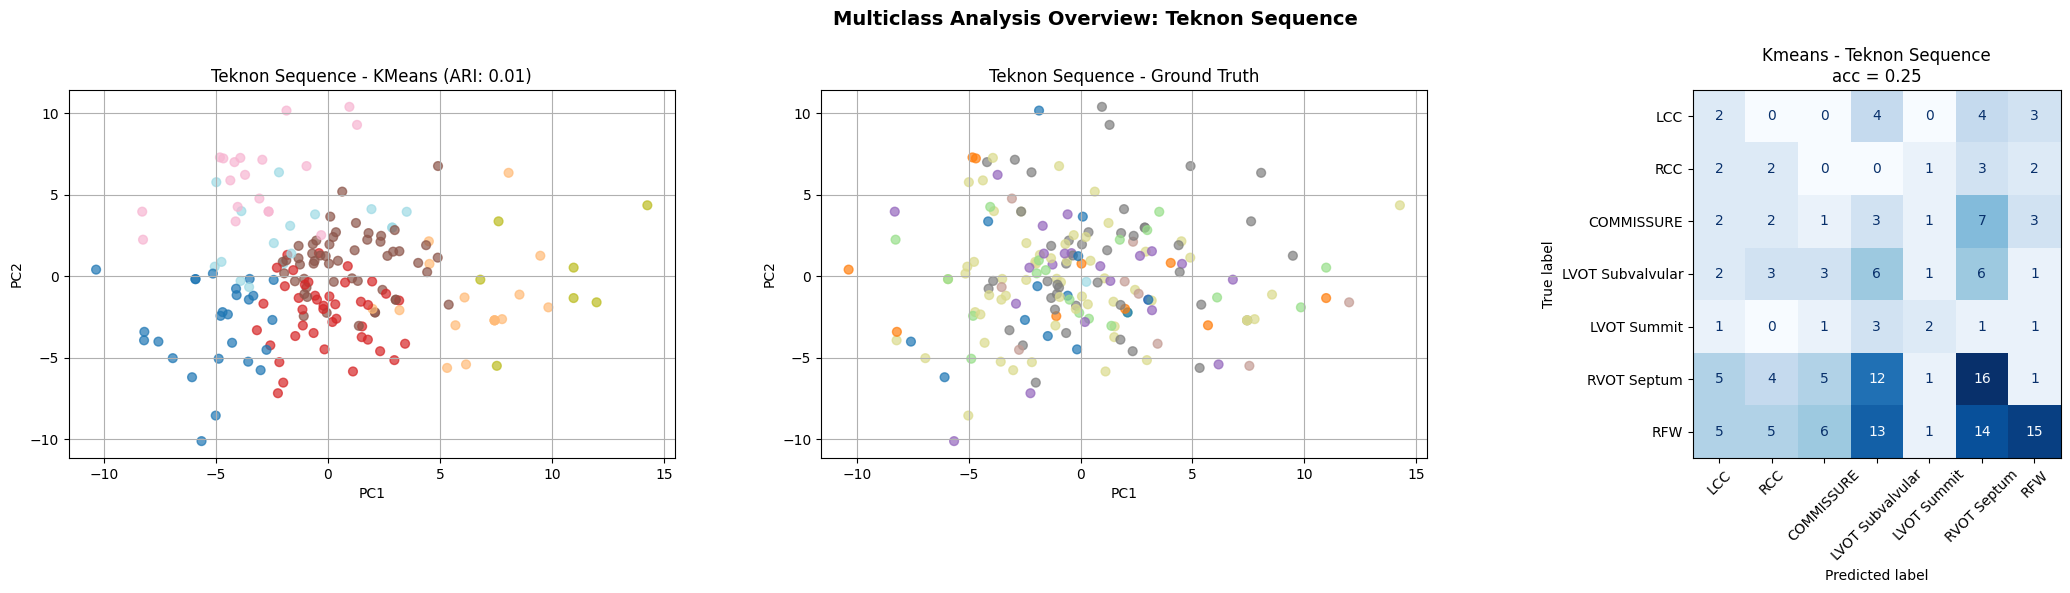

In [ ]:
# Load multi-class records preserving patient distribution matrices
X_Sims_mul, _, y_sub_Sims = load_mat_dataset(PATH_SIMS, data_key='QRS_Sims', sample_size=10, is_multiclass=True)
X_China_mul, _, y_sub_China = load_mat_dataset(PATH_CHINA, data_key='QRS', sample_size=10, is_multiclass=True)
X_Clinic_mul, _, y_sub_Clinic = load_mat_dataset(PATH_CARTO, data_key='QRS_CARTO', sample_size=10, is_multiclass=True)
X_tek_mul, y_sub_tek, encoder_mul = load_teknon_dataset(PATH_MULTICLASS_PARQUET, 'Final_Label')

multiclass_experiments = [
    ("Simulations (SIMS)", X_Sims_mul, y_sub_Sims),
    ("Database (CHINA)", X_China_mul, y_sub_China),
    ("Clinical Mapping (CARTO)", X_Clinic_mul, y_sub_Clinic),
    ("Teknon Sequence", X_tek_mul, y_sub_tek)
]

# Extract morphological configurations and process complex sub-classes
for dataset_name, X_tensor, y_sub_labels in multiclass_experiments:
    print(f"\nExecuting Sublocation Pipeline on: {dataset_name}")

    # Flat features evaluation profile
    F_matrix, _ = extract_features(X_tensor)
    F_scaled = StandardScaler().fit_transform(F_matrix)

    # Perform latent projection
    pca_transformer = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca_transformer.fit_transform(F_scaled)

    # Cluster optimization using expected structural regions (K=7 mappings)
    kmeans_model = KMeans(n_clusters=7, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    cluster_labels = kmeans_model.fit_predict(F_scaled)
    cluster_mapped = match_multiclass_labels(y_sub_labels, cluster_labels, n_clusters=7)

    # Extract structural similarity indexes
    acc = np.mean(cluster_mapped == y_sub_labels)
    ari = adjusted_rand_score(y_sub_labels, cluster_labels)
    nmi = normalized_mutual_info_score(y_sub_labels, cluster_labels)
    cm = confusion_matrix(y_sub_labels, cluster_mapped, labels=range(7))
    print(f"  > Accuracy (Matched): {acc:.4f}")
    print(f"  > Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"  > Normalized Mutual Info (NMI): {nmi:.4f}")

    # Visualization(Ground Truth vs Unsupervised K-Means)
    fig,axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 6), squeeze=False)
    fig.suptitle(f"Multiclass Analysis Overview: {dataset_name}", fontsize=14, fontweight='bold')

    # Column 0: Unsupervised KMeans Scatter Map
    scatter_km = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab20', alpha=0.7, s=40)
    axes[0, 0].set_title(f"{dataset_name} - KMeans (ARI: {ari:.2f})")
    axes[0, 0].set_xlabel("PC1")
    axes[0, 0].set_ylabel("PC2")
    axes[0, 0].grid(True)

    # Column 1: Ground Truth Label Scatter Map
    scatter_gt = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_sub_labels, cmap='tab20', alpha=0.7, s=40)
    axes[0, 1].set_title(f"{dataset_name} - Ground Truth")
    axes[0, 1].set_xlabel("PC1")
    axes[0, 1].set_ylabel("PC2")
    axes[0, 1].grid(True)

    # Column 2: Aligned Multiclass Confusion Matrix Heatmap
    # Generate labels array safely from SUBLOCATION_MAPPING
    labels_display = [k for k, v in sorted(SUBLOCATION_MAPPING.items(), key=lambda item: item[1]) if v < 7]

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_display)
    disp.plot(ax=axes[0, 2], cmap='Blues', colorbar=False, xticks_rotation=45)
    axes[0, 2].set_title(f"Kmeans - {dataset_name}\nacc = {acc:.2f}")

    plt.tight_layout()
    plt.show()
    plt.close()